Importando Biblioteca KERAS

In [1]:
import tensorflow
from tensorflow import keras

In [5]:
dataset = keras.datasets.fashion_mnist
((train_imgs, train_labels), (test_imgs, test_labels)) = dataset.load_data()

# separate the dataset: train | test

#print(len(train_imgs))
#print(len(test_imgs))

train_imgs.shape # itens, lines, columns
test_imgs.shape

(10000, 28, 28)

Visualização do conjunto de dados

In [6]:
import matplotlib.pyplot as plt

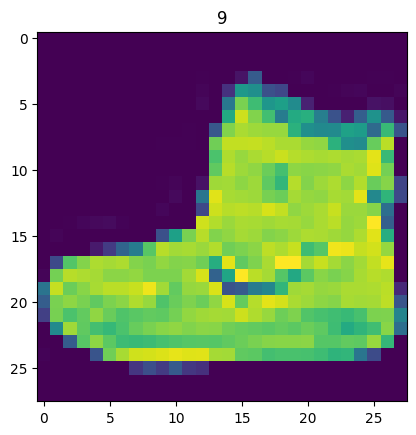

In [8]:
plt.imshow(train_imgs[0])
plt.title(train_labels[0])
plt.show()

# https://github.com/zalandoresearch/fashion-mnist

In [10]:
classes_names = [
 	'Camiseta',
 	'Calça',
 	'Pullover',
 	'Vestido',
 	'Casaco',
 	'Sandalha',
 	'Camisa',
 	'Tênis',
 	'Bolsa',
 	'Bota'
]

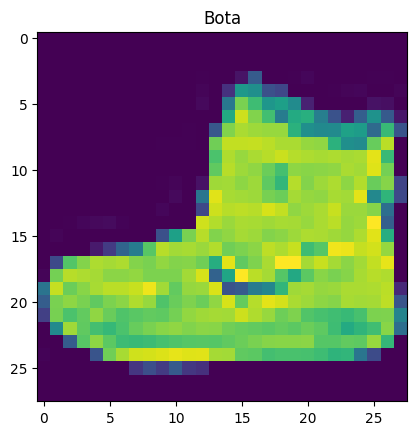

In [12]:
plt.imshow(train_imgs[0])
plt.title(classes_names[train_labels[0]])
plt.show()

TREINAMENTO OTIMIZAÇÃO

In [24]:
train_imgs = train_imgs/255 # Limitando o range para [0 ... 1]
test_imgs = test_imgs/255

CRIANDO MODELO

In [25]:
from tensorflow.keras import layers, models

# camadas
model = models.Sequential(
    [
        # Camada de compressão para vetor de 788 números
        layers.Flatten(input_shape=(28,28)),

        # Camadas Intermediárias - Neurônios Intermediários
        layers.Dense(256, activation=tensorflow.nn.relu),

        # Camada de Saída
        layers.Dense(10, activation=tensorflow.nn.softmax)
    ]
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy'
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


TREINO DO MODELO

In [26]:
model.fit(train_imgs, train_labels,
          epochs=2,       # tentativa de melhoramento com múltiplas épocas
          batch_size=32   # 32 imagens por vez, todas as 60000 imgs em cada época
          )

Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.4835
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.3636


TESTAR O MODELO

In [33]:
predicao = model.predict(test_imgs)

import numpy as np

np.argmax(predicao[0]) # 9 = bota

print(f'Predição do modelo: {classes_names[np.argmax(predicao[17])]}')
print(f'Dado Real: {classes_names[test_labels[17]]}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predição do modelo: Pullover
Dado Real: Casaco
